# Step 2: Handling Missing Values
## Feature Engineering Series — Deep Dive

Missing data is unavoidable in real-world datasets. The goal is not just to **fill gaps** — it is to fill them **intelligently** without introducing bias or leaking information.

### Datasets used:
| Dataset | Domain | Why useful here |
|---------|--------|-----------------|
| **Titanic** | Passenger survival | Mixed types, several missing columns |
| **Tips** | Restaurant tipping | Clean dataset (we'll inject missingness to demonstrate) |
| **California Housing** | House price prediction | Numeric missingness in real estate context |

### Three main strategies covered:
1. **Imputation** — mean, median, mode, constant, and model-based
2. **Indicator Variables** — flagging where data was missing
3. **Dropping** — rows and columns with too much missing data

---

## 0. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

# --- Load datasets ---
titanic = sns.load_dataset('titanic')
tips    = sns.load_dataset('tips')

cal_raw  = fetch_california_housing()
housing  = pd.DataFrame(cal_raw.data, columns=cal_raw.feature_names)
housing['Price'] = cal_raw.target

print('Datasets loaded:')
print(f'  Titanic  : {titanic.shape}')
print(f'  Tips     : {tips.shape}')
print(f'  Housing  : {housing.shape}')

# quick missing summary
# percentage of missing values in each column
def missing_summary(df, label=''):
    m = pd.DataFrame({
        'missing': df.isnull().sum(),
        'pct':     (df.isnull().sum() / len(df) * 100).round(1)
    })
    m = m[m['missing'] > 0].sort_values('pct', ascending=False)
    if label:
        print(f'\nMissing values — {label}:')
    return m

print('\nTitanic missing values:')
display(missing_summary(titanic, 'Titanic'))

Datasets loaded:
  Titanic  : (891, 15)
  Tips     : (244, 7)
  Housing  : (20640, 9)

Titanic missing values:

Missing values — Titanic:


,missing,pct
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2


---
##  Background: Types of Missingness

Before choosing a strategy, ask: **why is this data missing?**

| Type | Full Name | Meaning | Best Strategy |
|------|-----------|---------|---------------|
| **MCAR** | Missing Completely At Random | Missingness unrelated to any data | Any imputation safe |
| **MAR** | Missing At Random | Missingness depends on *other observed* columns | Model-based or grouped imputation |
| **MNAR** | Missing Not At Random | Missingness depends on the *missing value itself* | Indicator variable + domain knowledge |

> **Example:** A patient skips recording their weight because they are overweight (MNAR). Simply imputing the mean would systematically underestimate missing weights.

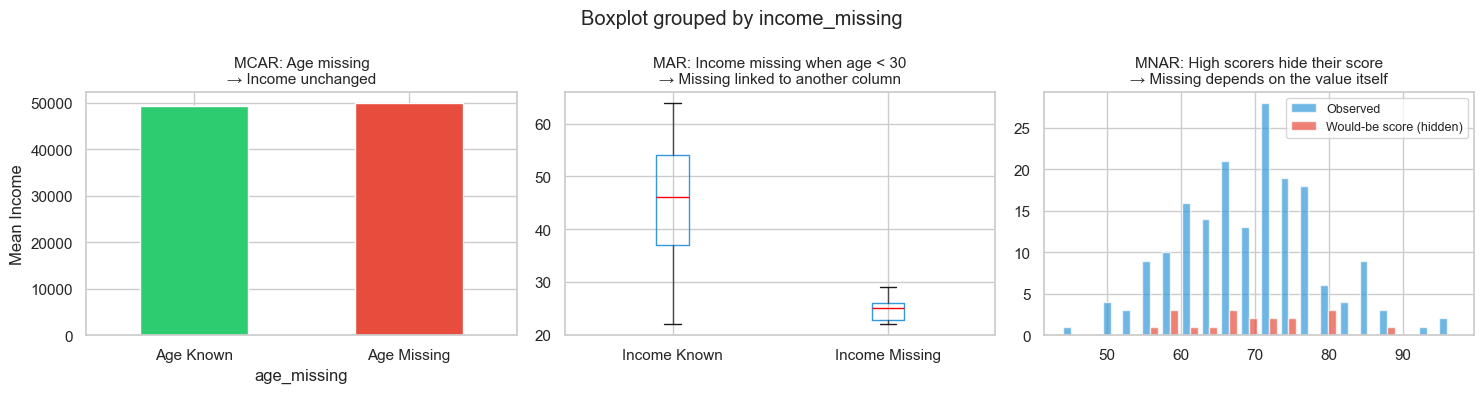

Takeaway: Always visualize why data is missing before choosing a fix!


In [4]:
# =============================================
# Demonstrate the 3 types using synthetic data
# =============================================
np.random.seed(42)
n = 200
demo = pd.DataFrame({
    'income':  np.random.normal(50000, 15000, n).clip(15000),
    'age':     np.random.randint(22, 65, n),
    'score':   np.random.normal(70, 10, n).clip(0, 100)
})

# MCAR — random 15% missing in 'age'
mcar_idx = np.random.choice(n, int(0.15*n), replace=False)
demo.loc[mcar_idx, 'age'] = np.nan

# MAR — income missing when age < 30
mar_idx = demo[demo['age'] < 30].sample(frac=0.6, random_state=42).index
demo.loc[mar_idx, 'income'] = np.nan

# MNAR — score missing for high scorers (self-selection)
mnar_idx = demo[demo['score'] > 80].sample(frac=0.55, random_state=42).index
demo.loc[mnar_idx, 'score'] = np.nan

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# MCAR — no pattern in age by missingness
demo['age_missing'] = demo['age'].isnull()
demo.groupby('age_missing')['income'].mean().plot(kind='bar', ax=axes[0],
    color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_xticklabels(['Age Known', 'Age Missing'], rotation=0)
axes[0].set_title('MCAR: Age missing\n→ Income unchanged', fontsize=11)
axes[0].set_ylabel('Mean Income')

# MAR — income missing only when young
demo['income_missing'] = demo['income'].isnull()
demo.boxplot(column='age', by='income_missing', ax=axes[1],
             boxprops=dict(color='#3498db'), medianprops=dict(color='red'))
axes[1].set_title('MAR: Income missing when age < 30\n→ Missing linked to another column', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Income Known', 'Income Missing'])

# MNAR — score missing for high scorers
demo['score_missing'] = demo['score'].isnull()
# Show what the actual scores of missing people WOULD have been
np.random.seed(42)
score_full = np.random.normal(70, 10, n).clip(0, 100)
axes[2].hist([score_full[~demo['score_missing']], score_full[demo['score_missing']]],
             bins=20, label=['Observed', 'Would-be score (hidden)'],
             color=['#3498db','#e74c3c'], alpha=0.7, edgecolor='white')
axes[2].set_title('MNAR: High scorers hide their score\n→ Missing depends on the value itself', fontsize=11)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Takeaway: Always visualize why data is missing before choosing a fix!')

---
#  Strategy 1 — Imputation

**Imputation** means filling missing values with an estimated substitute.

We'll cover 5 types:
- **1A** Mean imputation
- **1B** Median imputation
- **1C** Mode imputation (categorical)
- **1D** Constant / domain value imputation
- **1E** Model-based: KNN & Iterative (MICE)
- **1F** Grouped imputation (conditional on another column)

EXAMPLE 1A — Mean Imputation

When to use: Numeric feature, roughly symmetric distribution,
             and missingness is MCAR (random).
When NOT to use: Skewed data or when outliers inflate the mean.

AveRooms: injected 4128 missing values (20.0%)
NaN check — true_values has NaN: False
Mean value used for imputation: 5.429
NaN check — imputed has NaN:    False
RMSE vs true values:            0.0000


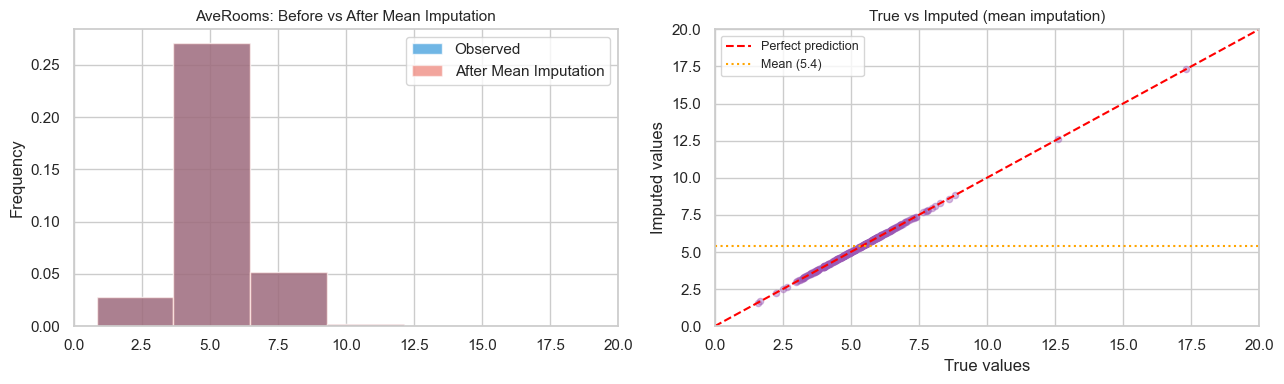

 Mean imputation creates a spike at the mean — distorts variance.
   All missing values get the SAME value regardless of other features.


In [8]:
# =============================================
# EXAMPLE 1A — Mean Imputation  (FIXED)
# Dataset: California Housing (inject missing in 'AveRooms')
# =============================================
print('=' * 55)
print('EXAMPLE 1A — Mean Imputation')
print('=' * 55)
print()
print('When to use: Numeric feature, roughly symmetric distribution,')
print('             and missingness is MCAR (random).')
print('When NOT to use: Skewed data or when outliers inflate the mean.')
print()

np.random.seed(0)
housing_demo = housing.copy()

# ── FIX 1: capture true values BEFORE injecting NaN ──────
missing_positions = np.random.choice(len(housing_demo), int(0.20 * len(housing_demo)), replace=False)
true_values = housing_demo['AveRooms'].iloc[missing_positions].copy()   # use .iloc (position-based)

# Now inject NaN
housing_demo['AveRooms'].iloc[missing_positions] = np.nan
print(f'AveRooms: injected {len(missing_positions)} missing values '
      f'({len(missing_positions)/len(housing_demo)*100:.1f}%)')
print(f'NaN check — true_values has NaN: {true_values.isna().any()}')   # should be False

# Apply mean imputation
mean_val = housing_demo['AveRooms'].mean()
housing_mean = housing_demo.copy()

# ── FIX 2: use .iloc for retrieval, consistent with injection ─
housing_mean['AveRooms'].fillna(mean_val, inplace=True)
imputed = housing_mean['AveRooms'].iloc[missing_positions]

print(f'Mean value used for imputation: {mean_val:.3f}')
print(f'NaN check — imputed has NaN:    {imputed.isna().any()}')         # should be False

# Now safe to compute RMSE
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(true_values, imputed))
print(f'RMSE vs true values:            {rmse:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

housing_demo['AveRooms'].dropna().plot(
    kind='hist', bins=50, ax=axes[0],
    alpha=0.7, color='#3498db', label='Observed', edgecolor='white', density=True)
housing_mean['AveRooms'].plot(
    kind='hist', bins=50, ax=axes[0],
    alpha=0.5, color='#e74c3c', label='After Mean Imputation', edgecolor='white', density=True)
axes[0].set_title('AveRooms: Before vs After Mean Imputation', fontsize=11)
axes[0].legend()
axes[0].set_xlim(0, 20)

axes[1].scatter(true_values.values[:300], imputed.values[:300],
                alpha=0.4, color='#9b59b6', s=20)
lims = [0, 20]
axes[1].plot(lims, lims, color='red', linestyle='--', label='Perfect prediction')
axes[1].axhline(mean_val, color='orange', linestyle=':', label=f'Mean ({mean_val:.1f})')
axes[1].set_xlabel('True values')
axes[1].set_ylabel('Imputed values')
axes[1].set_title('True vs Imputed (mean imputation)', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].set_xlim(*lims); axes[1].set_ylim(*lims)

plt.tight_layout()
plt.show()
print(' Mean imputation creates a spike at the mean — distorts variance.')
print('   All missing values get the SAME value regardless of other features.')

EXAMPLE 1B — Median Imputation

When to use: Numeric feature with SKEWED distribution or outliers.
             Median is resistant to extreme values.

Age mean   = 29.70
Age median = 28.00
Difference = 1.70 years  ← skew effect


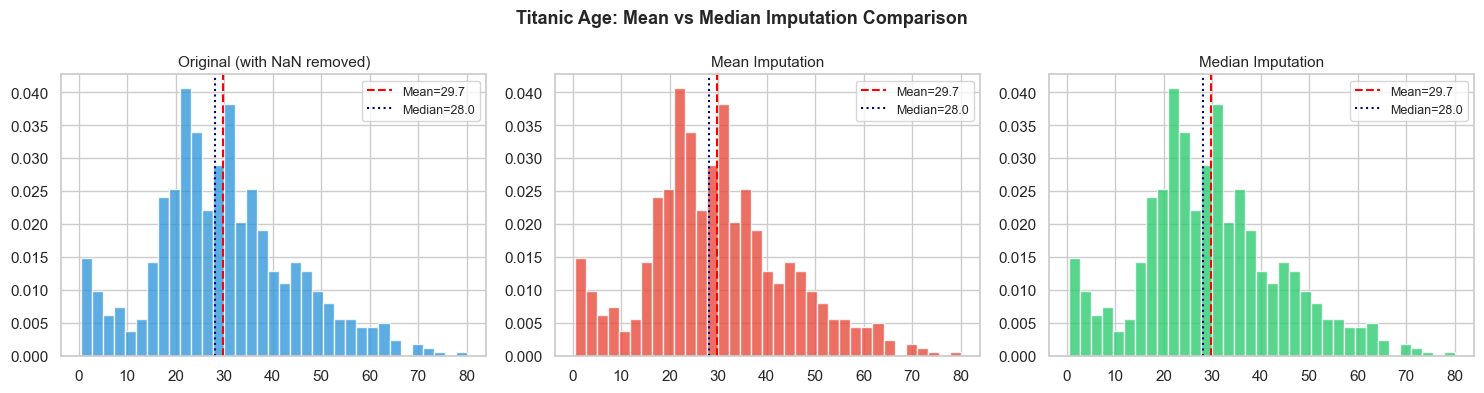


✅  For age (right-skewed), median imputation is preferred.
    It avoids over-imputing toward older ages caused by high-fare outliers.


In [ ]:
# =============================================
# EXAMPLE 1B — Median Imputation
# Dataset: Titanic 'age' (right-skewed, has outliers)
# =============================================
print('=' * 55)
print('EXAMPLE 1B — Median Imputation')
print('=' * 55)
print()
print('When to use: Numeric feature with SKEWED distribution or outliers.')
print('             Median is resistant to extreme values.')
print()

t = titanic.copy()
age_mean   = t['age'].mean()
age_median = t['age'].median()
print(f'Age mean   = {age_mean:.2f}')
print(f'Age median = {age_median:.2f}')
print(f'Difference = {abs(age_mean - age_median):.2f} years  ← skew effect')

t_mean   = t.copy(); t_mean['age'].fillna(age_mean, inplace=True)
t_median = t.copy(); t_median['age'].fillna(age_median, inplace=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

titles = ['Original (with NaN removed)', 'Mean Imputation', 'Median Imputation']
datas  = [t['age'].dropna(), t_mean['age'], t_median['age']]
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (ax, data, title, color) in enumerate(zip(axes, datas, titles, colors)):
    ax.hist(data, bins=35, color=color, edgecolor='white', alpha=0.8, density=True)
    ax.axvline(data.mean(),   color='red',    linestyle='--', label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color='navy',   linestyle=':',  label=f'Median={data.median():.1f}')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Titanic Age: Mean vs Median Imputation Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print()
print('For age (right-skewed), median imputation is preferred.')
print('  It avoids over-imputing toward older ages caused by high-fare outliers.')

EXAMPLE 1C — Mode Imputation (Categorical)

When to use: Categorical / ordinal columns.
             Replaces missing entries with the most frequent category.

Before imputation:
  embarked value counts:
embarked
S    644
C    168
Q     77
Name: count, dtype: int64
  Missing: 2

Mode used: "S"
Missing after imputation: 2


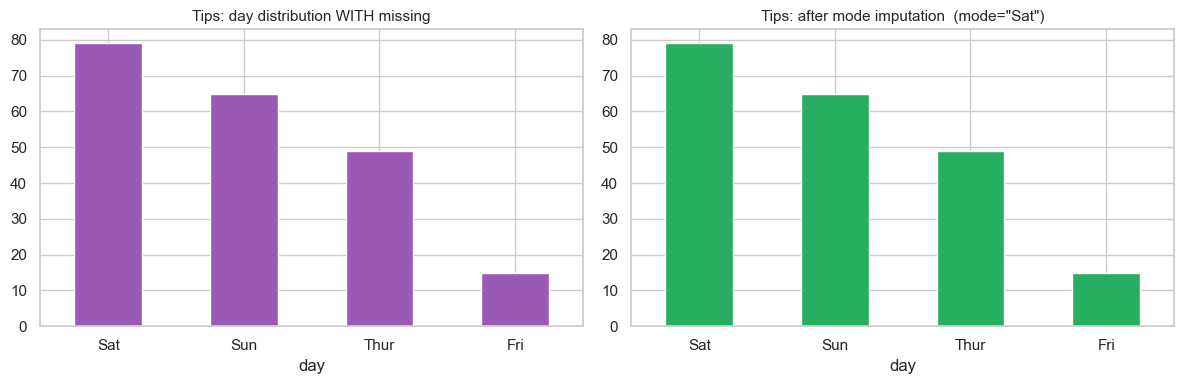

  Mode imputation can over-represent the most frequent category.
    Acceptable for very few missing values; risky for high missingness.


In [9]:
# =============================================
# EXAMPLE 1C — Mode Imputation (Categorical)
# Dataset: Titanic 'embarked' (2 missing values)
# =============================================
print('=' * 55)
print('EXAMPLE 1C — Mode Imputation (Categorical)')
print('=' * 55)
print()
print('When to use: Categorical / ordinal columns.')
print('             Replaces missing entries with the most frequent category.')
print()

t2 = titanic.copy()
print('Before imputation:')
print(f'  embarked value counts:\n{t2["embarked"].value_counts()}')
print(f'  Missing: {t2["embarked"].isnull().sum()}')

mode_val = t2['embarked'].mode()[0]
t2['embarked'].fillna(mode_val, inplace=True)
print(f'\nMode used: "{mode_val}"')
print(f'Missing after imputation: {t2["embarked"].isnull().sum()}')

# Also demonstrate on a more ambiguous case with tips dataset — inject 15% missing in 'day'
tips_demo = tips.copy()
np.random.seed(7)
miss_idx = np.random.choice(len(tips_demo), int(0.15*len(tips_demo)), replace=False)
tips_demo.loc[miss_idx, 'day'] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tips_demo['day'].value_counts().plot(kind='bar', ax=axes[0], color='#9b59b6',
                                      edgecolor='white')
axes[0].set_title('Tips: day distribution WITH missing', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)

tips_demo['day'].fillna(tips_demo['day'].mode()[0], inplace=True)
tips_demo['day'].value_counts().plot(kind='bar', ax=axes[1], color='#27ae60',
                                      edgecolor='white')
axes[1].set_title(f'Tips: after mode imputation  (mode="{tips["day"].mode()[0]}")', fontsize=11)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print('  Mode imputation can over-represent the most frequent category.')
print('    Acceptable for very few missing values; risky for high missingness.')

EXAMPLE 1D — Constant / Domain Value Imputation

When to use: When a missing value has a meaningful interpretation.
  - Missing "deck" → passenger had no recorded cabin (likely 3rd class)
  - Missing "previous_employer" → first job applicant
  - Missing "number_of_children" → likely 0

deck dtype:   category
deck missing: 688 (77.2%)
After fillna("Unknown"):
deck_filled
Unknown    688
C           59
B           47
D           33
E           32
A           15
F           13
Name: count, dtype: int64

Employee bonus: 58 missing (30%)
Domain rule: missing bonus = no bonus received → fill with 0


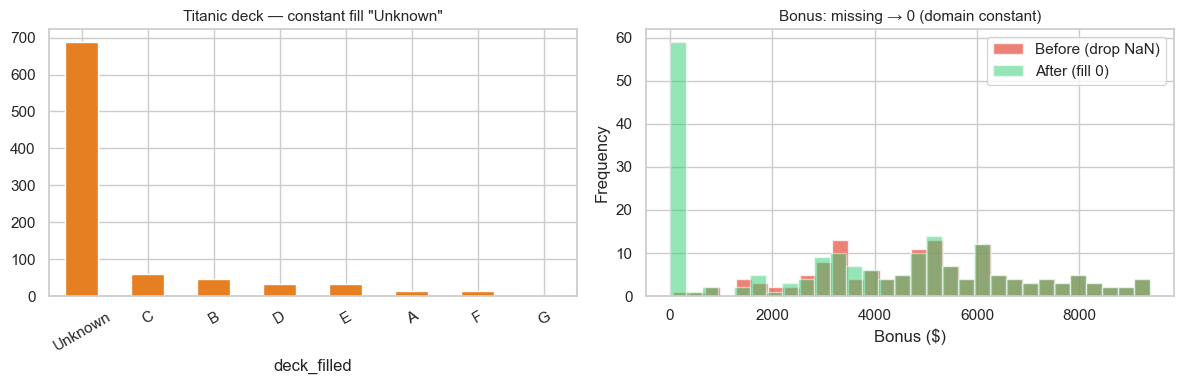

✅ Domain-driven constants are the most interpretable imputation strategy.


In [ ]:
# =============================================
# EXAMPLE 1D — Constant / Domain Value Imputation (FIXED)
# =============================================
print('=' * 55)
print('EXAMPLE 1D — Constant / Domain Value Imputation')
print('=' * 55)
print()
print('When to use: When a missing value has a meaningful interpretation.')
print('  - Missing "deck" → passenger had no recorded cabin (likely 3rd class)')
print('  - Missing "previous_employer" → first job applicant')
print('  - Missing "number_of_children" → likely 0')
print()

t3 = titanic.copy()

# Case 1: deck — fill with 'Unknown'
# FIX: deck is Categorical dtype → must add 'Unknown' to categories first
print(f'deck dtype:   {t3["deck"].dtype}')          # shows: category
print(f'deck missing: {t3["deck"].isnull().sum()} ({t3["deck"].isnull().mean()*100:.1f}%)')

t3['deck_filled'] = (
    t3['deck']
    .cat.add_categories('Unknown')  # register new category before filling
    .fillna('Unknown')
)

print('After fillna("Unknown"):')
print(t3['deck_filled'].value_counts().head(7))

# Case 2: Numeric with domain default
np.random.seed(42)
employees = pd.DataFrame({
    'employee_id': range(1, 201),
    'salary': np.random.normal(60000, 15000, 200).clip(25000),
    'bonus': np.where(
        np.random.rand(200) < 0.3,
        np.nan,
        np.random.normal(5000, 2000, 200).clip(0)
    )
})
print(f'\nEmployee bonus: {employees["bonus"].isnull().sum()} missing (30%)')
print('Domain rule: missing bonus = no bonus received → fill with 0')
employees['bonus_filled'] = employees['bonus'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

t3['deck_filled'].value_counts().plot(
    kind='bar', ax=axes[0], color='#e67e22', edgecolor='white')
axes[0].set_title('Titanic deck — constant fill "Unknown"', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

employees['bonus'].plot(
    kind='hist', bins=30, ax=axes[1], alpha=0.7,
    color='#e74c3c', label='Before (drop NaN)', edgecolor='white')
employees['bonus_filled'].plot(
    kind='hist', bins=30, ax=axes[1], alpha=0.5,
    color='#2ecc71', label='After (fill 0)', edgecolor='white')
axes[1].set_title('Bonus: missing → 0 (domain constant)', fontsize=11)
axes[1].legend()
axes[1].set_xlabel('Bonus ($)')

plt.tight_layout()
plt.show()
print('Domain-driven constants are the most interpretable imputation strategy.')

EXAMPLE 1E — Grouped / Conditional Imputation

When to use: When the missing feature is correlated with another
             known column. Compute imputation stat within groups.

Median age by class & sex:
sex     female  male
pclass              
1         35.0  40.0
2         28.0  30.0
3         21.5  25.0

Global median age: 28.0

Sample of how grouped differs from global:


,pclass,sex,global_fill,grouped_fill,difference
5,3,male,28.0,25.0,-3.0
17,2,male,28.0,30.0,2.0
19,3,female,28.0,21.5,-6.5
26,3,male,28.0,25.0,-3.0
28,3,female,28.0,21.5,-6.5
29,3,male,28.0,25.0,-3.0
31,1,female,28.0,35.0,7.0
32,3,female,28.0,21.5,-6.5
36,3,male,28.0,25.0,-3.0
42,3,male,28.0,25.0,-3.0


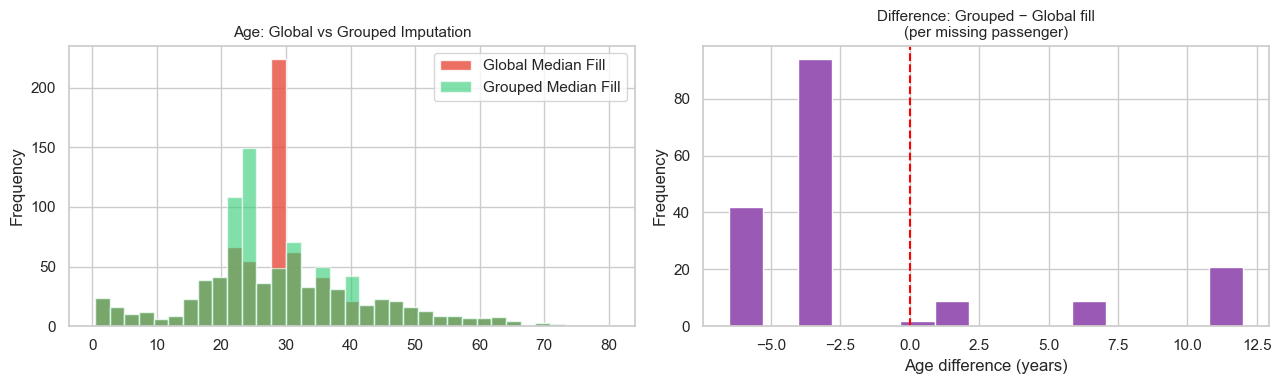

  Grouped imputation uses richer context → closer to the true value.


In [11]:
# =============================================
# EXAMPLE 1E — Grouped / Conditional Imputation
# Dataset: Titanic 'age' conditioned on 'pclass' and 'sex'
# =============================================
print('=' * 55)
print('EXAMPLE 1E — Grouped / Conditional Imputation')
print('=' * 55)
print()
print('When to use: When the missing feature is correlated with another')
print('             known column. Compute imputation stat within groups.')
print()

t4 = titanic.copy()

# Show that age varies by class and sex
group_medians = t4.groupby(['pclass','sex'])['age'].median()
print('Median age by class & sex:')
print(group_medians.unstack())

# Compare: global median vs grouped median
global_median = t4['age'].median()

t4['age_global'] = t4['age'].fillna(global_median)

def fill_by_group(row):
    if pd.isnull(row['age']):
        return group_medians.get((row['pclass'], row['sex']), global_median)
    return row['age']

t4['age_grouped'] = t4.apply(fill_by_group, axis=1)

# Show the difference for missing rows
missing_rows = titanic[titanic['age'].isnull()][['pclass','sex']].copy()
missing_rows['global_fill']  = global_median
missing_rows['grouped_fill'] = missing_rows.apply(
    lambda r: group_medians.get((r['pclass'], r['sex']), global_median), axis=1)
missing_rows['difference'] = (missing_rows['grouped_fill'] - missing_rows['global_fill']).round(1)

print(f'\nGlobal median age: {global_median}')
print('\nSample of how grouped differs from global:')
display(missing_rows.head(12))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

t4['age_global'].plot(kind='hist', bins=35, ax=axes[0], color='#e74c3c',
    edgecolor='white', alpha=0.8, label='Global Median Fill')
t4['age_grouped'].plot(kind='hist', bins=35, ax=axes[0], color='#2ecc71',
    edgecolor='white', alpha=0.6, label='Grouped Median Fill')
axes[0].set_title('Age: Global vs Grouped Imputation', fontsize=11)
axes[0].legend()

missing_rows['difference'].plot(kind='hist', bins=15, ax=axes[1],
    color='#9b59b6', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Difference: Grouped − Global fill\n(per missing passenger)', fontsize=11)
axes[1].set_xlabel('Age difference (years)')

plt.tight_layout()
plt.show()
print('  Grouped imputation uses richer context → closer to the true value.')

EXAMPLE 1F — KNN Imputation

How it works:
  For each missing value, KNN finds the k most similar rows
  (using non-missing features) and averages their values.

When to use: Moderate-sized dataset (<50k rows), features are correlated.
When NOT to:  Very large datasets (slow), unrelated features.

Injected 300 missing values in AveRooms
  KNN k=3: RMSE=2.5981
  KNN k=5: RMSE=2.4193
  KNN k=10: RMSE=2.8821
  Mean fill:  RMSE=2.3241


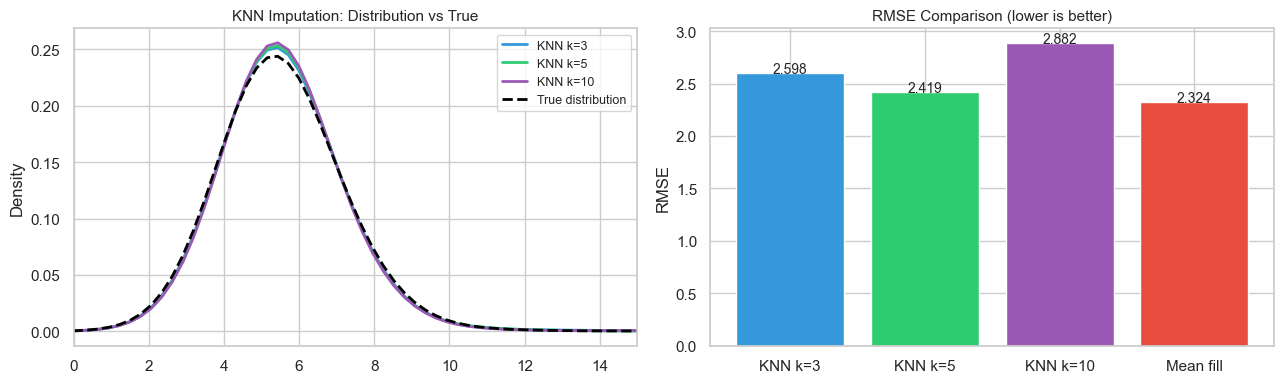

 KNN outperforms mean imputation by leveraging feature similarity.


In [12]:
# =============================================
# EXAMPLE 1F — KNN Imputation
# Dataset: California Housing (inject missing)
# =============================================
print('=' * 55)
print('EXAMPLE 1F — KNN Imputation')
print('=' * 55)
print()
print('How it works:')
print('  For each missing value, KNN finds the k most similar rows')
print('  (using non-missing features) and averages their values.')
print()
print('When to use: Moderate-sized dataset (<50k rows), features are correlated.')
print('When NOT to:  Very large datasets (slow), unrelated features.')
print()

# Inject 15% missing into AveBedrms and AveRooms
np.random.seed(1)
h = housing[['MedInc','HouseAge','AveRooms','AveBedrms','Population']].copy().iloc[:2000]

true_rooms = h['AveRooms'].copy()
missing_idx2 = np.random.choice(len(h), int(0.15*len(h)), replace=False)
h.loc[h.index[missing_idx2], 'AveRooms'] = np.nan
print(f'Injected {len(missing_idx2)} missing values in AveRooms')

# KNN with different k values
results = {}
for k in [3, 5, 10]:
    knn = KNNImputer(n_neighbors=k)
    h_imp = pd.DataFrame(knn.fit_transform(h), columns=h.columns, index=h.index)
    imputed_vals = h_imp.loc[h.index[missing_idx2], 'AveRooms']
    true_vals    = true_rooms.iloc[missing_idx2]
    rmse = np.sqrt(mean_squared_error(true_vals, imputed_vals))
    results[f'KNN k={k}'] = {'imputed': h_imp['AveRooms'], 'rmse': rmse}
    print(f'  KNN k={k}: RMSE={rmse:.4f}')

# Compare with mean
mean_fill = h['AveRooms'].mean()
mean_imputed = h['AveRooms'].fillna(mean_fill)
mean_rmse = np.sqrt(mean_squared_error(true_rooms.iloc[missing_idx2],
                                        [mean_fill]*len(missing_idx2)))
print(f'  Mean fill:  RMSE={mean_rmse:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for k, label, color in [(3,'KNN k=3','#3498db'),(5,'KNN k=5','#2ecc71'),(10,'KNN k=10','#9b59b6')]:
    results[f'KNN k={k}']['imputed'].plot(kind='kde', ax=axes[0], label=label, color=color, linewidth=2)
true_rooms.plot(kind='kde', ax=axes[0], color='black', linewidth=2, linestyle='--', label='True distribution')
axes[0].set_title('KNN Imputation: Distribution vs True', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 15)

rmse_vals = [results[f'KNN k={k}']['rmse'] for k in [3,5,10]] + [mean_rmse]
labels    = ['KNN k=3', 'KNN k=5', 'KNN k=10', 'Mean fill']
colors    = ['#3498db', '#2ecc71', '#9b59b6', '#e74c3c']
axes[1].bar(labels, rmse_vals, color=colors, edgecolor='white')
axes[1].set_title('RMSE Comparison (lower is better)', fontsize=11)
axes[1].set_ylabel('RMSE')
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()
print(' KNN outperforms mean imputation by leveraging feature similarity.')

EXAMPLE 1G — Iterative (MICE) Imputation

How it works:
  MICE = Multiple Imputation by Chained Equations.
  Treats each column with missingness as a regression target,
  predicted from all other columns. Repeats until convergence.

When to use: MAR data with multiple correlated missing columns.
  Most statistically rigorous method, but slowest.

AveRooms:
  MICE RMSE:        0.7538
  Mean fill RMSE:   1.1095
  Improvement:      32.1%
AveBedrms:
  MICE RMSE:        0.1530
  Mean fill RMSE:   0.1784
  Improvement:      14.3%


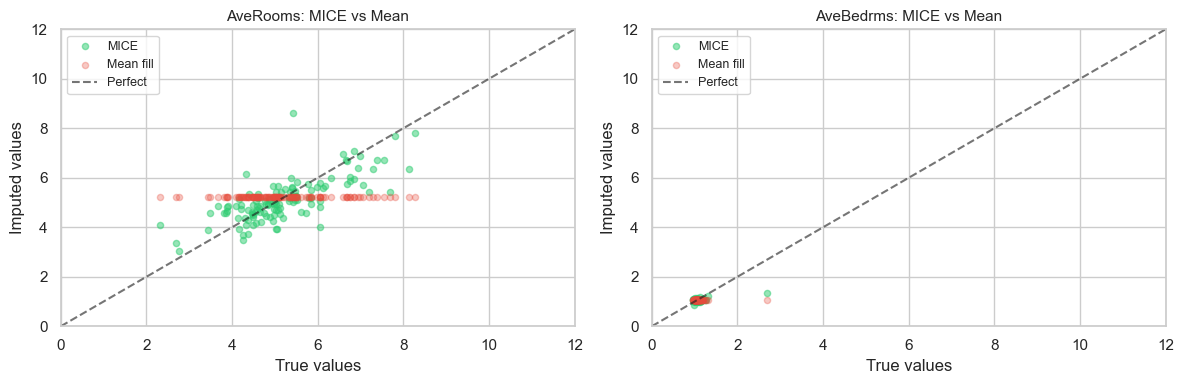

MICE produces imputed values that preserve correlations between features.


In [13]:
# =============================================
# EXAMPLE 1G — Iterative Imputation (MICE)
# Dataset: California Housing
# =============================================
print('=' * 55)
print('EXAMPLE 1G — Iterative (MICE) Imputation')
print('=' * 55)
print()
print('How it works:')
print('  MICE = Multiple Imputation by Chained Equations.')
print('  Treats each column with missingness as a regression target,')
print('  predicted from all other columns. Repeats until convergence.')
print()
print('When to use: MAR data with multiple correlated missing columns.')
print('  Most statistically rigorous method, but slowest.')
print()

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

np.random.seed(42)
h2 = housing[['MedInc','HouseAge','AveRooms','AveBedrms']].copy().iloc[:1000]

true_rooms2 = h2['AveRooms'].copy()
true_bedrooms = h2['AveBedrms'].copy()
miss_r = np.random.choice(len(h2), 120, replace=False)
miss_b = np.random.choice(len(h2), 100, replace=False)
h2.iloc[miss_r, h2.columns.get_loc('AveRooms')]    = np.nan
h2.iloc[miss_b, h2.columns.get_loc('AveBedrms')]   = np.nan

# Iterative imputer
mice = IterativeImputer(estimator=BayesianRidge(), max_iter=10, random_state=42)
h2_mice = pd.DataFrame(mice.fit_transform(h2), columns=h2.columns)

# Simple mean for comparison
simple = SimpleImputer(strategy='mean')
h2_simple = pd.DataFrame(simple.fit_transform(h2), columns=h2.columns)

# Evaluate
for col, true_v, miss_i in [('AveRooms', true_rooms2, miss_r),
                              ('AveBedrms', true_bedrooms, miss_b)]:
    rmse_mice   = np.sqrt(mean_squared_error(true_v.iloc[miss_i], h2_mice.iloc[miss_i][col]))
    rmse_simple = np.sqrt(mean_squared_error(true_v.iloc[miss_i], h2_simple.iloc[miss_i][col]))
    print(f'{col}:')
    print(f'  MICE RMSE:        {rmse_mice:.4f}')
    print(f'  Mean fill RMSE:   {rmse_simple:.4f}')
    print(f'  Improvement:      {(rmse_simple-rmse_mice)/rmse_simple*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for col, true_v, ax, miss_i in [('AveRooms', true_rooms2, axes[0], miss_r),
                                  ('AveBedrms', true_bedrooms, axes[1], miss_b)]:
    ax.scatter(true_v.iloc[miss_i], h2_mice.iloc[miss_i][col], alpha=0.5,
               color='#2ecc71', s=20, label='MICE')
    ax.scatter(true_v.iloc[miss_i], h2_simple.iloc[miss_i][col], alpha=0.3,
               color='#e74c3c', s=20, label='Mean fill')
    lim = max(true_v.quantile(0.99), 12)
    ax.plot([0, lim], [0, lim], 'k--', alpha=0.6, label='Perfect')
    ax.set_xlabel('True values'); ax.set_ylabel('Imputed values')
    ax.set_title(f'{col}: MICE vs Mean', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)

plt.tight_layout()
plt.show()
print('MICE produces imputed values that preserve correlations between features.')

---
#  Strategy 2 — Indicator Variables (Missingness Flags)

**Key insight:** The *fact* that a value is missing can itself be informative.

Adding a binary flag column `feature_missing = 1` alongside imputation lets the model learn:
- whether missingness predicts the target, AND
- what the imputed value predicts

### When to use:
- Missingness is MNAR or MAR (not random)
- You have reason to believe the act of not reporting carries signal
- Always pair with any imputation strategy

EXAMPLE 2A — Indicator Variable: Titanic age
Passengers with age missing: 177
Passengers with age known:   714


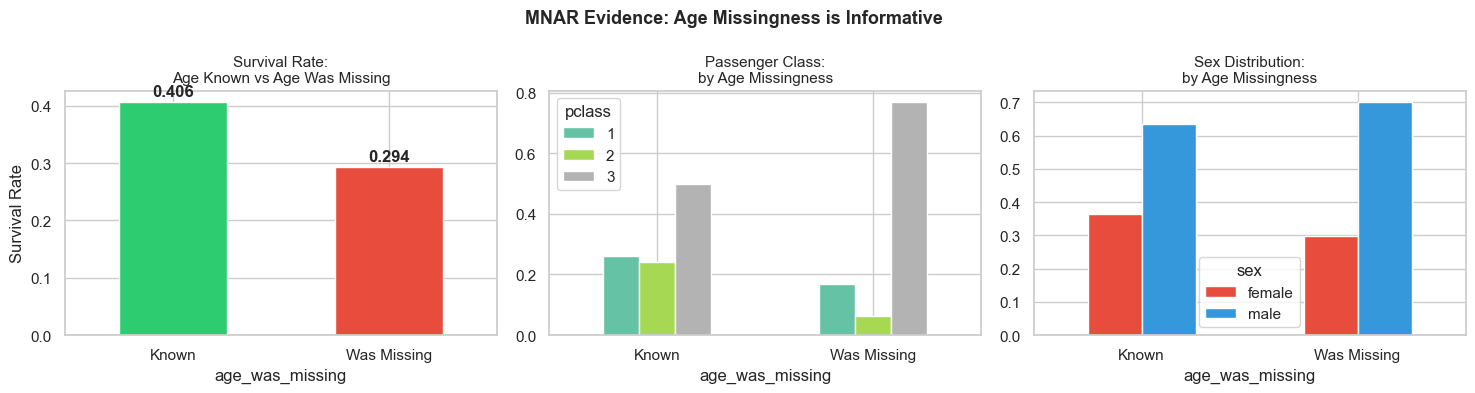

Finding: Passengers with missing age survived at a LOWER rate (29% vs 41%).
→ This flag is a PREDICTIVE FEATURE — do not discard this information!


In [14]:
# =============================================
# EXAMPLE 2A — Indicator Variable: Titanic age
# =============================================
print('=' * 55)
print('EXAMPLE 2A — Indicator Variable: Titanic age')
print('=' * 55)

t5 = titanic.copy()

# Create binary flag BEFORE imputing
t5['age_was_missing'] = t5['age'].isnull().astype(int)
t5['age'].fillna(t5['age'].median(), inplace=True)

print(f'Passengers with age missing: {t5["age_was_missing"].sum()}')
print(f'Passengers with age known:   {(t5["age_was_missing"]==0).sum()}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Survival rate by indicator
surv = t5.groupby('age_was_missing')['survived'].mean()
surv.plot(kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Survival Rate:\nAge Known vs Age Was Missing', fontsize=11)
axes[0].set_xticklabels(['Known', 'Was Missing'], rotation=0)
axes[0].set_ylabel('Survival Rate')
for i, v in enumerate(surv): axes[0].text(i, v+0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Class distribution by indicator
pd.crosstab(t5['age_was_missing'], t5['pclass'], normalize='index').plot(
    kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('Passenger Class:\nby Age Missingness', fontsize=11)
axes[1].set_xticklabels(['Known','Was Missing'], rotation=0)
axes[1].legend(title='pclass')

# Sex distribution by indicator
pd.crosstab(t5['age_was_missing'], t5['sex'], normalize='index').plot(
    kind='bar', ax=axes[2], color=['#e74c3c','#3498db'], edgecolor='white')
axes[2].set_title('Sex Distribution:\nby Age Missingness', fontsize=11)
axes[2].set_xticklabels(['Known','Was Missing'], rotation=0)

plt.suptitle('MNAR Evidence: Age Missingness is Informative', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Finding: Passengers with missing age survived at a LOWER rate (29% vs 41%).')
print('→ This flag is a PREDICTIVE FEATURE — do not discard this information!')

In [15]:
# =============================================
# EXAMPLE 2B — Model performance WITH vs WITHOUT indicator
# =============================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

print('=' * 55)
print('EXAMPLE 2B — Impact of Indicator Variables on Model')
print('=' * 55)

t6 = titanic.copy()
t6['sex_enc'] = LabelEncoder().fit_transform(t6['sex'])
t6['embarked'].fillna('S', inplace=True)
t6['embarked_enc'] = LabelEncoder().fit_transform(t6['embarked'])

# Without indicator
t6['age'].fillna(t6['age'].median(), inplace=True)
features_base = ['pclass','sex_enc','age','fare','sibsp','parch','embarked_enc']

# With indicator
t6['age_was_missing'] = titanic['age'].isnull().astype(int)
features_with_flag = features_base + ['age_was_missing']

t6['fare'].fillna(t6['fare'].median(), inplace=True)
X_all = t6[features_with_flag].dropna()
y_all = t6.loc[X_all.index, 'survived']

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

results = {}
for label, feats in [('Without flag', features_base), ('With age_was_missing flag', features_with_flag)]:
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X_tr[feats], y_tr)
    preds = rf.predict(X_te[feats])
    proba = rf.predict_proba(X_te[feats])[:, 1]
    acc   = accuracy_score(y_te, preds)
    auc   = roc_auc_score(y_te, proba)
    results[label] = {'accuracy': acc, 'AUC': auc}
    print(f'{label}: Accuracy={acc:.4f}  AUC={auc:.4f}')

print(f"\nAUC improvement: +{results['With age_was_missing flag']['AUC'] - results['Without flag']['AUC']:.4f}")
print(' Adding the missingness flag improved model discrimination.')

EXAMPLE 2B — Impact of Indicator Variables on Model
Without flag: Accuracy=0.7622  AUC=0.8264
With age_was_missing flag: Accuracy=0.7832  AUC=0.8283

AUC improvement: +0.0019
 Adding the missingness flag improved model discrimination.


EXAMPLE 2C — Multiple Indicator Variables (Medical)

In medical data, which tests were ordered is itself clinical information.
A missing lab value often means the test was not ordered, which may
indicate the doctor deemed it unlikely/unnecessary.

Missing counts:
age              0
bmi              0
glucose          0
cholesterol    100
creatinine      93
diagnosis        0
dtype: int64

Indicator variables created:
['cholesterol_missing', 'creatinine_missing']

Mean diagnosis by creatinine missingness:
creatinine_missing
Test ordered        0.341523
Test NOT ordered    1.000000
Name: diagnosis, dtype: float64


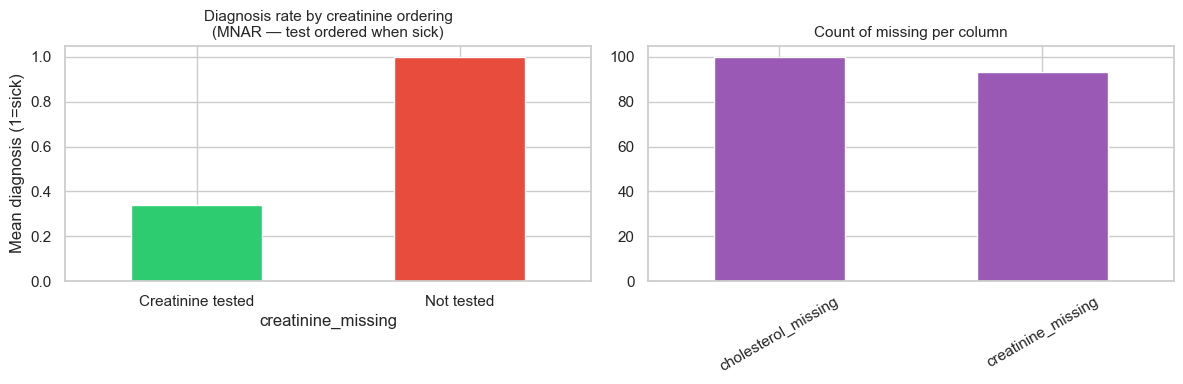

In [25]:
# =============================================
# EXAMPLE 2C — Multiple Indicator Variables
# Dataset: Synthetic medical dataset
# =============================================
print('=' * 55)
print('EXAMPLE 2C — Multiple Indicator Variables (Medical)')
print('=' * 55)
print()
print('In medical data, which tests were ordered is itself clinical information.')
print('A missing lab value often means the test was not ordered, which may')
print('indicate the doctor deemed it unlikely/unnecessary.')
print()

np.random.seed(0)
n = 500
patients = pd.DataFrame({
    'age':       np.random.randint(20, 85, n),
    'bmi':       np.random.normal(27, 5, n).clip(15, 55),
    'glucose':   np.random.normal(100, 25, n).clip(60, 400),
    'cholesterol': np.random.normal(200, 40, n).clip(100, 400),
    'creatinine': np.random.normal(1.0, 0.4, n).clip(0.3, 5),
    'diagnosis': np.random.randint(0, 2, n)
})

# Simulate clinical missingness (MNAR — sicker patients more likely to have tests)
sick_idx = patients[patients['diagnosis']==1].sample(frac=0.4, random_state=1).index
patients.loc[sick_idx, 'creatinine'] = np.nan  # kidney panel not ordered for healthier patients
patients.loc[np.random.choice(n, 100, replace=False), 'cholesterol'] = np.nan

print('Missing counts:')
print(patients.isnull().sum())

# Create indicator matrix
indicator_df = patients.isnull().astype(int).add_suffix('_missing')
indicator_df = indicator_df[[c for c in indicator_df.columns if indicator_df[c].sum() > 0]]
print('\nIndicator variables created:')
print(indicator_df.columns.tolist())

# Verify that creatinine missingness predicts diagnosis
print('\nMean diagnosis by creatinine missingness:')
combined = pd.concat([patients[['diagnosis']], indicator_df], axis=1)
print(combined.groupby('creatinine_missing')['diagnosis'].mean().rename({0:'Test ordered', 1:'Test NOT ordered'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

combined.groupby('creatinine_missing')['diagnosis'].mean().plot(
    kind='bar', ax=axes[0], color=['#2ecc71','#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_xticklabels(['Creatinine tested', 'Not tested'], rotation=0)
axes[0].set_title('Diagnosis rate by creatinine ordering\n(MNAR — test ordered when sick)', fontsize=11)
axes[0].set_ylabel('Mean diagnosis (1=sick)')

indicator_df.sum().plot(kind='bar', ax=axes[1], color='#9b59b6', edgecolor='white')
axes[1].set_title('Count of missing per column', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

---
#  Strategy 3 — Dropping Rows and Columns

Sometimes the best fix is **removal**. But be careful — dropping data too aggressively causes bias.

### Rules of thumb:
| Situation | Action |
|-----------|--------|
| Column > 60% missing | Drop column |
| Column < 5% missing | Consider dropping rows |
| Column between 5–60% | Impute |
| Row missing most features | Drop row |
| Missingness is MCAR | Dropping rows is unbiased |
| Missingness is MNAR/MAR | Dropping rows introduces bias |

EXAMPLE 3A — Drop Columns by Missing Threshold
Current missing %:
Population    80.0
AveBedrms     65.0
AveRooms      35.0
HouseAge      12.0
MedInc         2.0
dtype: float64

Threshold 30%: drop ['Population', 'AveBedrms', 'AveRooms'] → keep 6/9 columns

Threshold 50%: drop ['Population', 'AveBedrms'] → keep 7/9 columns

Threshold 70%: drop ['Population'] → keep 8/9 columns


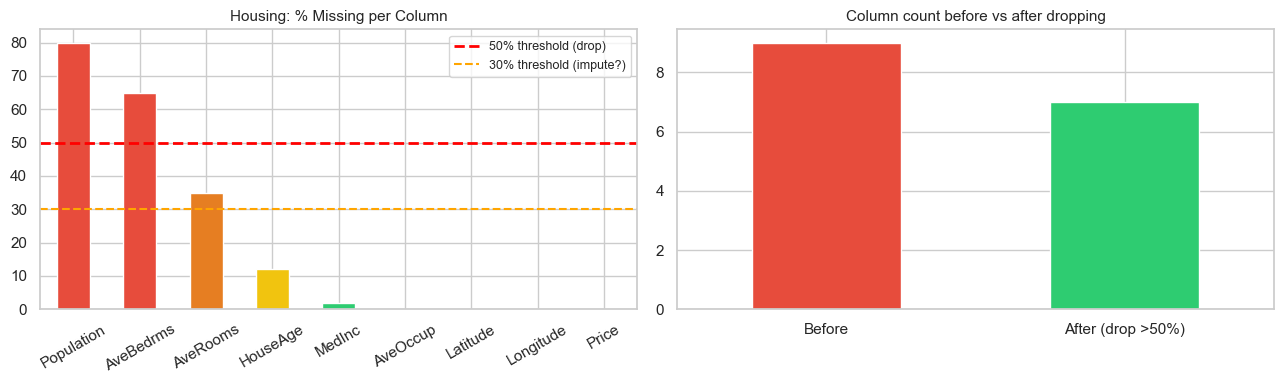


Dropped columns: ['Population', 'AveBedrms']
Remaining: ['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'Latitude', 'Longitude', 'Price']


In [17]:
# =============================================
# EXAMPLE 3A — Drop Columns by Missing Threshold
# =============================================
print('=' * 55)
print('EXAMPLE 3A — Drop Columns by Missing Threshold')
print('=' * 55)

# Inject varying levels of missing into housing
np.random.seed(0)
h_drop = housing.copy()
for col, frac in [('MedInc', 0.02), ('HouseAge', 0.12),
                  ('AveRooms', 0.35), ('AveBedrms', 0.65),
                  ('Population', 0.80)]:
    idx = np.random.choice(len(h_drop), int(frac*len(h_drop)), replace=False)
    h_drop.iloc[idx, h_drop.columns.get_loc(col)] = np.nan

pct_missing = (h_drop.isnull().sum() / len(h_drop) * 100).sort_values(ascending=False)
print('Current missing %:')
print(pct_missing[pct_missing > 0].round(1))

# Apply different thresholds
for threshold in [30, 50, 70]:
    cols_to_drop = pct_missing[pct_missing > threshold].index.tolist()
    kept = h_drop.shape[1] - len(cols_to_drop)
    print(f'\nThreshold {threshold}%: drop {cols_to_drop} → keep {kept}/{h_drop.shape[1]} columns')

# Apply 50% threshold
cols_to_drop = pct_missing[pct_missing > 50].index.tolist()
h_dropped_cols = h_drop.drop(columns=cols_to_drop)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Missing % bar chart
colors = ['#e74c3c' if p > 50 else '#e67e22' if p > 30 else '#f1c40f' if p > 10 else '#2ecc71'
          for p in pct_missing]
pct_missing.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].axhline(50, color='red', linestyle='--', linewidth=2, label='50% threshold (drop)')
axes[0].axhline(30, color='orange', linestyle='--', linewidth=1.5, label='30% threshold (impute?)')
axes[0].set_title('Housing: % Missing per Column', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=30)

# Before vs after
pd.Series({'Before': h_drop.shape[1], 'After (drop >50%)': h_dropped_cols.shape[1]}).plot(
    kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], edgecolor='white', width=0.5)
axes[1].set_title('Column count before vs after dropping', fontsize=11)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print(f'\nDropped columns: {cols_to_drop}')
print(f'Remaining: {list(h_dropped_cols.columns)}')

EXAMPLE 3B — Dropping Rows

Case 1 — embarked missing: 2 rows dropped
  891 → 889 rows  (loss: 0.22%)
   Safe: only 0.22% data lost, likely MCAR

Case 2 — age missing: 177 rows dropped
  891 → 714 rows  (loss: 19.9%)
  Survival rate (all data):     0.384
  Survival rate (age known):    0.406
  Survival rate (age missing):  0.294
    Bias introduced: 0.022 difference in target mean!
     Dropping age-missing rows OVER-REPRESENTS survivors!


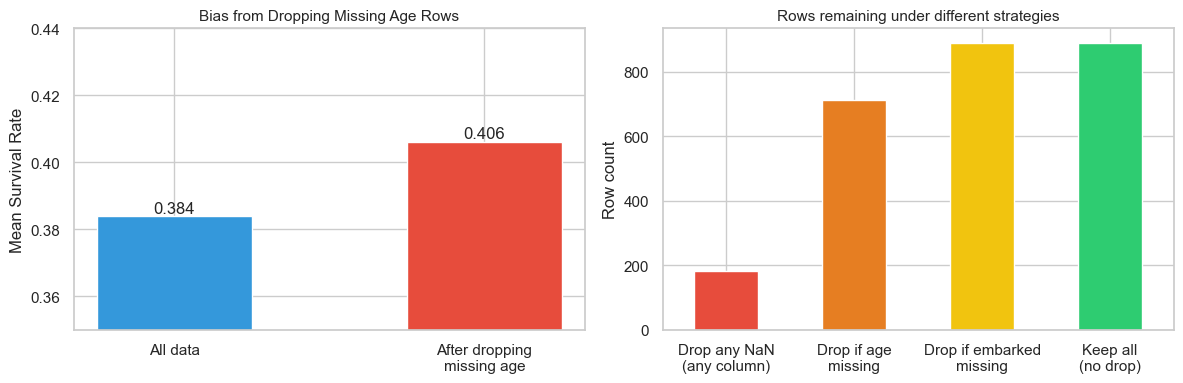

In [18]:
# =============================================
# EXAMPLE 3B — Drop Rows (when missing is MCAR and small)
# Dataset: Titanic 'embarked' (only 2 missing)
# =============================================
print('=' * 55)
print('EXAMPLE 3B — Dropping Rows')
print('=' * 55)
print()

t7 = titanic.copy()

# Case 1: drop rows where embarked is missing (only 2 rows)
n_before = len(t7)
t7_dropped = t7.dropna(subset=['embarked'])
n_after = len(t7_dropped)
print(f'Case 1 — embarked missing: {n_before - n_after} rows dropped')
print(f'  {n_before} → {n_after} rows  (loss: {(n_before-n_after)/n_before*100:.2f}%)')
print('   Safe: only 0.22% data lost, likely MCAR')

# Case 2: drop rows where age is missing (177 rows — bad idea)
n_before2 = len(t7)
t7_age_dropped = t7.dropna(subset=['age'])
n_after2 = len(t7_age_dropped)
print(f'\nCase 2 — age missing: {n_before2 - n_after2} rows dropped')
print(f'  {n_before2} → {n_after2} rows  (loss: {(n_before2-n_after2)/n_before2*100:.1f}%)')

# Show bias introduced by dropping age rows
full_surv   = t7['survived'].mean()
dropped_surv = t7_age_dropped['survived'].mean()
missing_surv = t7[t7['age'].isnull()]['survived'].mean()
print(f'  Survival rate (all data):     {full_surv:.3f}')
print(f'  Survival rate (age known):    {dropped_surv:.3f}')
print(f'  Survival rate (age missing):  {missing_surv:.3f}')
print(f'    Bias introduced: {abs(dropped_surv - full_surv):.3f} difference in target mean!')
print('     Dropping age-missing rows OVER-REPRESENTS survivors!')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Survival bias visualization
bars = axes[0].bar(['All data', 'After dropping\nmissing age'],
                    [full_surv, dropped_surv],
                    color=['#3498db', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Bias from Dropping Missing Age Rows', fontsize=11)
axes[0].set_ylabel('Mean Survival Rate')
axes[0].set_ylim(0.35, 0.44)
for bar, v in zip(bars, [full_surv, dropped_surv]):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.001, f'{v:.3f}', ha='center')

# Show how much data we lose with different dropna strategies
strategies = {
    'Drop any NaN\n(any column)': len(t7.dropna()),
    'Drop if age\nmissing': len(t7_age_dropped),
    'Drop if embarked\nmissing': len(t7_dropped),
    'Keep all\n(no drop)': len(t7)
}
pd.Series(strategies).plot(kind='bar', ax=axes[1],
    color=['#e74c3c','#e67e22','#f1c40f','#2ecc71'], edgecolor='white')
axes[1].set_title('Rows remaining under different strategies', fontsize=11)
axes[1].set_ylabel('Row count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

EXAMPLE 3C — Row Completeness Threshold

Strategy: Drop rows where more than X% of features are missing.
These rows are often data entry errors or edge cases.

Row completeness distribution:
completeness_pct
100    346
90      91
80      26
70      23
50       8
20       2
0        4
Name: count, dtype: int64
Require 50% completeness: keep 494, drop 6
Require 70% completeness: keep 486, drop 14
Require 90% completeness: keep 437, drop 63


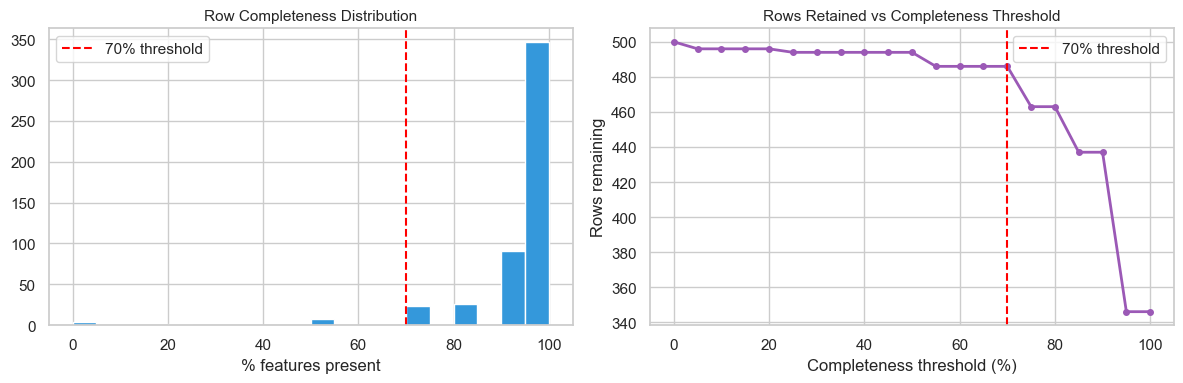

In [19]:
# =============================================
# EXAMPLE 3C — Drop rows with too many missing features
# (Row-level completeness threshold)
# =============================================
print('=' * 55)
print('EXAMPLE 3C — Row Completeness Threshold')
print('=' * 55)
print()
print('Strategy: Drop rows where more than X% of features are missing.')
print('These rows are often data entry errors or edge cases.')
print()

# Synthetic dataset with rows of varying completeness
np.random.seed(5)
n_rows, n_cols = 500, 10
sparse_data = pd.DataFrame(np.random.randn(n_rows, n_cols),
                            columns=[f'feature_{i}' for i in range(n_cols)])

# Introduce a mix of missing: some rows have many missing
for i in range(n_rows):
    n_missing = np.random.choice([0, 0, 0, 1, 1, 2, 3, 5, 8, 10],
                                  p=[0.35, 0.2, 0.15, 0.1, 0.08, 0.05, 0.04, 0.015, 0.01, 0.005])
    if n_missing > 0:
        miss_cols = np.random.choice(n_cols, n_missing, replace=False)
        sparse_data.iloc[i, miss_cols] = np.nan

# Compute completeness per row
sparse_data['completeness_pct'] = (sparse_data.notna().sum(axis=1) / n_cols * 100).astype(int)

print('Row completeness distribution:')
print(sparse_data['completeness_pct'].value_counts().sort_index(ascending=False).head(10))

# Apply threshold
for thresh in [50, 70, 90]:
    kept = (sparse_data['completeness_pct'] >= thresh).sum()
    dropped = n_rows - kept
    print(f'Require {thresh}% completeness: keep {kept}, drop {dropped}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sparse_data['completeness_pct'].hist(bins=20, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].axvline(70, color='red', linestyle='--', label='70% threshold')
axes[0].set_title('Row Completeness Distribution', fontsize=11)
axes[0].set_xlabel('% features present')
axes[0].legend()

# Impact of threshold
thresholds = list(range(0, 105, 5))
rows_kept = [(sparse_data['completeness_pct'] >= t).sum() for t in thresholds]
axes[1].plot(thresholds, rows_kept, color='#9b59b6', linewidth=2, marker='o', markersize=4)
axes[1].axvline(70, color='red', linestyle='--', label='70% threshold')
axes[1].set_xlabel('Completeness threshold (%)')
axes[1].set_ylabel('Rows remaining')
axes[1].set_title('Rows Retained vs Completeness Threshold', fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

---
#  Strategy Comparison — Side-by-Side

How do all methods compare on the same dataset and target?

FULL STRATEGY COMPARISON — Titanic Survival


,Strategy,Rows used,Accuracy,AUC-ROC
4,KNN (k=5),891,0.8101,0.8989
3,Grouped median,891,0.8156,0.8952
2,Median imputation,891,0.8156,0.8923
1,Mean imputation,891,0.8156,0.8880
5,Median + indicator,714,0.7832,0.8275
0,Drop rows (listwise),714,0.7692,0.8268


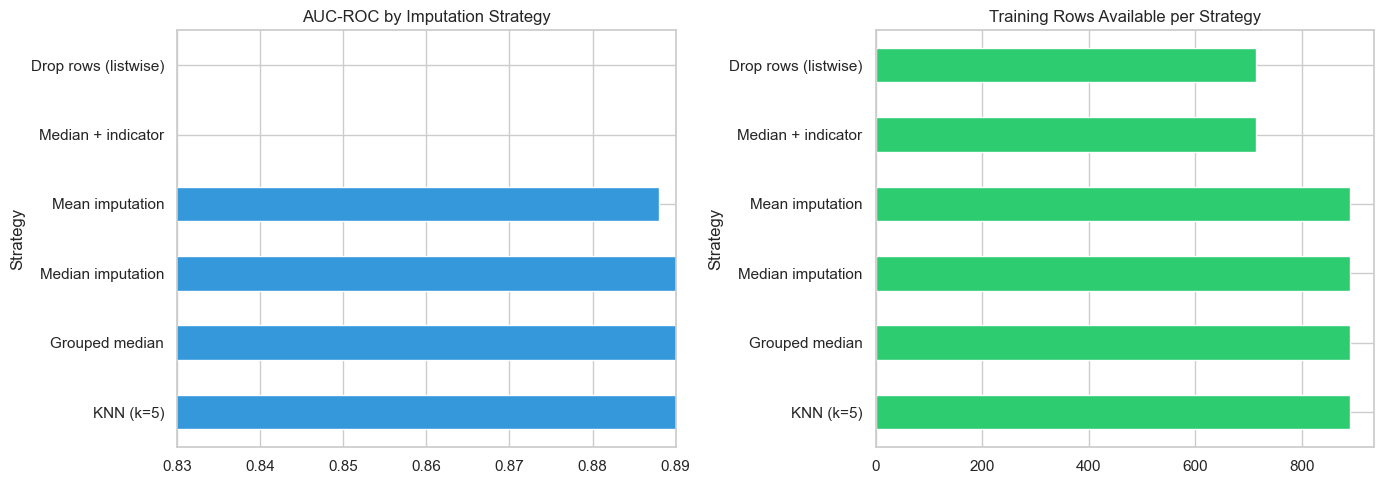

In [20]:
# =============================================
# EXAMPLE 4 — Full Comparison of All Strategies
# Dataset: Titanic survival prediction
# =============================================
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.metrics import roc_auc_score

print('=' * 55)
print('FULL STRATEGY COMPARISON — Titanic Survival')
print('=' * 55)

def prepare_titanic(df):
    d = df.copy()
    d['sex_enc'] = LabelEncoder().fit_transform(d['sex'])
    d['embarked_enc'] = LabelEncoder().fit_transform(d['embarked'].fillna('S'))
    d['fare'].fillna(d['fare'].median(), inplace=True)
    return d

base = prepare_titanic(titanic)
feats = ['pclass','sex_enc','age','fare','sibsp','parch','embarked_enc']
y_all = base['survived']

strategies = {
    'Drop rows (listwise)':   base.dropna(subset=['age']),
    'Mean imputation':        base.assign(age=base['age'].fillna(base['age'].mean())),
    'Median imputation':      base.assign(age=base['age'].fillna(base['age'].median())),
    'Grouped median':         base.assign(age=base.apply(
        lambda r: base.groupby(['pclass','sex_enc'])['age'].median().get(
            (r['pclass'], r['sex_enc']), base['age'].median()) if pd.isnull(r['age']) else r['age'], axis=1)),
}

# KNN strategy
knn_imp = KNNImputer(n_neighbors=5)
base_knn = base.copy()
base_knn[feats] = knn_imp.fit_transform(base_knn[feats])
strategies['KNN (k=5)'] = base_knn

# Median + indicator flag
base_flag = base.copy()
base_flag['age_flag'] = base_flag['age'].isnull().astype(int)
base_flag['age'].fillna(base_flag['age'].median(), inplace=True)
strategies['Median + indicator'] = base_flag
feats_flag = feats + ['age_flag']

results = []
for name, df_s in strategies.items():
    f = feats_flag if 'indicator' in name else feats
    df_clean = df_s.dropna(subset=f + ['survived'])
    X = df_clean[f]
    y = df_clean['survived']
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X_tr, y_tr)
    auc = roc_auc_score(y_te, rf.predict_proba(X_te)[:,1])
    acc = accuracy_score(y_te, rf.predict(X_te))
    results.append({'Strategy': name, 'Rows used': len(df_clean), 'Accuracy': acc, 'AUC-ROC': auc})

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)
display(results_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df.set_index('Strategy')['AUC-ROC'].plot(
    kind='barh', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('AUC-ROC by Imputation Strategy', fontsize=12)
axes[0].set_xlim(0.83, 0.89)
axes[0].axvline(results_df['AUC-ROC'].max(), color='red', linestyle='--', alpha=0.5)

results_df.set_index('Strategy')['Rows used'].plot(
    kind='barh', ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Training Rows Available per Strategy', fontsize=12)

plt.tight_layout()
plt.show()

---
#  Summary — Decision Guide

## Which strategy to use?

```
Missing data detected
        │
        ├── Column > 60% missing?
        │       └── YES → Drop column
        │
        ├── Only 1–5 rows missing in column?
        │       └── YES + MCAR → Drop rows (listwise)
        │
        ├── Categorical column?
        │       └── YES → Mode or constant fill ("Unknown")
        │
        ├── Numeric, symmetric distribution?
        │       └── YES + MCAR → Mean imputation
        │
        ├── Numeric, skewed or with outliers?
        │       └── YES → Median imputation
        │
        ├── Missingness related to other columns (MAR)?
        │       └── YES → Grouped median / KNN / MICE
        │
        ├── Missingness signals something (MNAR)?
        │       └── YES → Add indicator flag + impute
        │
        └── Multiple correlated columns with missingness?
                └── YES → MICE (Iterative Imputer)
```

## Quick Reference Table

| Strategy | Best for | Risk |
|----------|----------|------|
| Mean | MCAR numeric, symmetric | Distorts variance, sensitive to outliers |
| Median | Skewed numeric, outliers | Same spike issue, but more robust |
| Mode | Categorical | Over-represents majority class |
| Constant | Domain-driven default (0, 'Unknown') | Wrong if assumption incorrect |
| Grouped | MAR with correlated group | Requires stable groups |
| KNN | Moderate data, correlated features | Slow on large data |
| MICE | MAR, multiple columns | Slow, complex |
| Indicator flag | MNAR — missingness is informative | Always add alongside imputation |
| Drop columns | >60% missing | Lose features |
| Drop rows | MCAR, <5% missing | Introduces bias if MNAR |

### Golden Rules:
1. **Always visualize missingness** before choosing a strategy
2. **Never drop rows** when missingness is MNAR — it creates biased models
3. **Always add indicator flags** when missingness is informative
4. **Fit imputers on training data only** — never on the test set
5. **Compare strategies** on a held-out validation set